<a href="https://colab.research.google.com/github/AliefGr/Deep-Learning-1/blob/main/New_Menggunakan_Dataset_dari_TensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Membuat Model Menggunakan tf.data.Datasets
As usual, hal pertama yang kita lakukan adalah melakukan impor library TensorFlow agar dapat mengakses seluruh fungsi yang ada.

In [11]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds

Kemudian kita buat objek untuk menampung dataset kita dan masukkan fungsi tf.keras.datasets.<nama_dataset> pada objek tersebut. Karena pada kasus ini menggunakan dataset mnist, kode yang digunakan sebagai berikut.

In [4]:
mnist = tf.keras.datasets.mnist

Selanjutnya, kita perlu membagi dataset yang sudah ada menjadi dua bagian yaitu pelatihan dan uji menggunakan fungsi load_data(). Fungsi load_data() dari objek dataset mengembalikan bentuk dataset yang telah dibagi menjadi atribut latih, label latih, atribut uji, dan label uji. Sangat gampang, bukan? Hanya dengan beberapa baris kode kita sudah memiliki data latih dan data uji yang siap dipakai.

In [5]:
(gambar_latih, label_latih), (gambar_testing, label_testing) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Kita bisa menampilkan label dan salah satu gambar dari data latih menggunakan library matplotlib untuk memastikan data yang kita pilih sudah sesuai dan siap pakai.

5


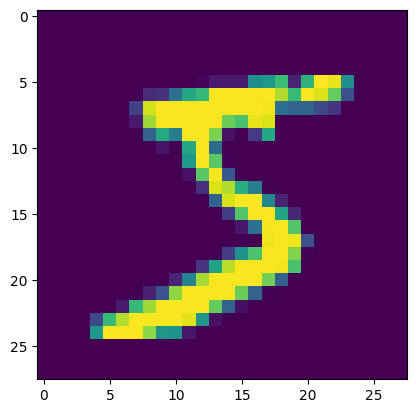

In [7]:
np.set_printoptions(linewidth=200)
plt.imshow(gambar_latih[0])
print(label_latih[0])

Namun, dataset yang kita miliki belum dinormalisasi sehingga kita harus melakukannya secara manual. Kode di bawah berfungsi untuk membagi setiap piksel pada gambar sebesar 255 karena nilai sebuah piksel berkisar dari 0 sampai 255.

In [8]:
gambar_latih  = gambar_latih / 255.0
gambar_testing = gambar_testing / 255.0

Dalam konteks pemrosesan citra atau pengenalan pola, normalisasi gambar sangat penting untuk memastikan bahwa nilai piksel berada dalam rentang yang dapat diolah dengan baik oleh model. Dalam hal ini, kode tersebut membagi nilai piksel dari gambar pelatihan (gambar_latih) dengan 255.0.

Karena nilai piksel pada umumnya dalam rentang 0 hingga 255, pembagian dengan nilai 255.0 akan menghasilkan nilai piksel yang lebih kecil yaitu dalam rentang 0 hingga 1. Ini membantu model pembelajaran mesin untuk belajar lebih efisien karena nilai yang lebih kecil cenderung memiliki efek yang lebih stabil selama proses pembelajaran.

Selanjutnya, kita akan menggunakan 3 layer sebagai arsitektur model ini. Untuk layer pertama, kita menggunakan layer khusus yaitu Flatten yang berfungsi untuk mengubah input kita yang berupa matriks 2 dimensi menjadi array 1 dimensi.

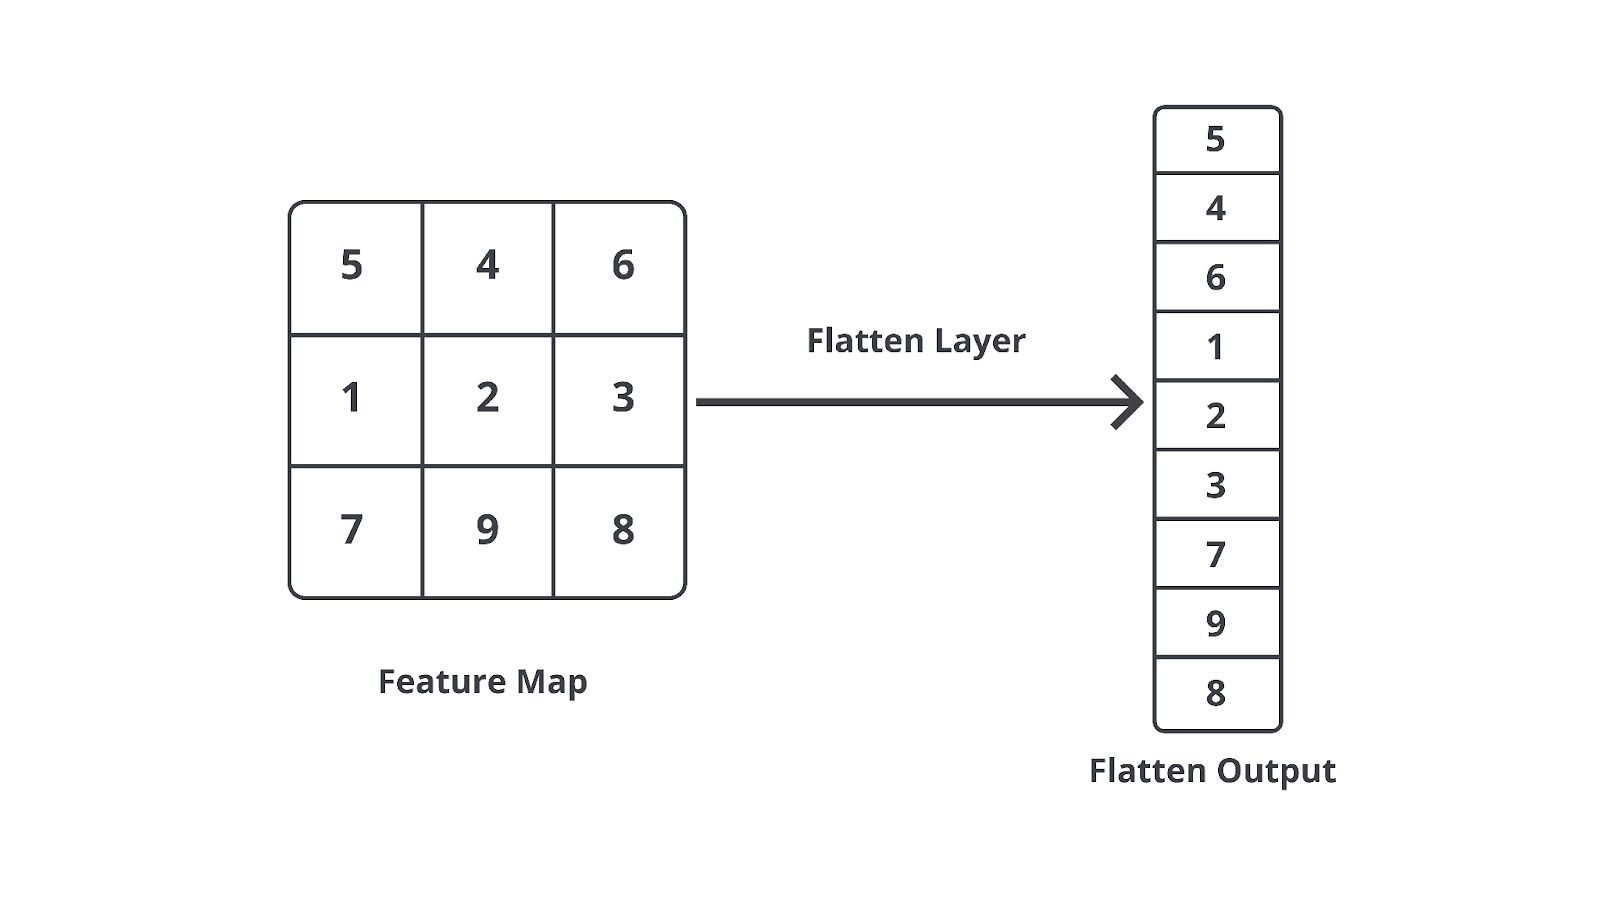

Untuk melakukan hal tersebut tentu sangatlah mudah jika menggunakan TensorFlow, kita hanya perlu memanggil layer Flatten dan mengisi parameter seperti biasanya.

In [9]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Terakhir, tentukan optimizer dan loss untuk model, lalu lakukan pelatihan pada model.

In [10]:
model.compile(optimizer = tf.optimizers.Adam(),
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(gambar_latih, label_latih, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8777 - loss: 0.4308
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9628 - loss: 0.1248
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9775 - loss: 0.0774
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9822 - loss: 0.0593
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9872 - loss: 0.0427


Sekarang, cobalah berlatih menggunakan dataset lain yang disediakan oleh TensorFlow Datasets. Kira-kira, apa yang berbeda? Bagaimana cara menggunakannya? Mari kita melangkah ke materi berikutnya untuk mendapatkan jawabannya.

# Membuat Model Menggunakan TensorFlow Datasets

TensorFlow menyediakan kumpulan dataset siap pakai untuk dilatih dengan TensorFlow, Jax, dan framework machine learning lainnya. TensorFlow Dataset (TFDS) bertugas untuk melakukan pengunduhan dan menyiapkan data secara deterministik dengan menggunakan tf.data.Dataset (atau np.array).

Sebelumnya, kita sudah mempelajari tf.data.Datasets, sekarang kita mengenal rivalnya yaitu TFDS. Namanya, cukup mirip, ya? Jangan bingung antara TFDS (library ini) dengan tf.data.Datasets (API dari TensorFlow).

TFDS adalah wrapper tingkat tinggi di sekitar tf.data. Jika Anda tidak terbiasa dengan API ini, kami menyarankan Anda untuk membaca panduan resmi dari TensorFlow pada tautan berikut: tf.data.

Di sisi lain, TFDS juga menyediakan lebih banyak datasets yang siap digunakan. Tanpa berlama-lama, mari kita mulai perjalanan ini dengan melakukan impor library yang akan digunakan.

Setelah berhasil menginstal library TFDS, kita dapat melihat list atau daftar dari dataset yang tersedia pada TFDS. Untuk melihat seluruh dataset yang tersedia, kita bisa menggunakan fungsi tfds.list_builders() atau dapat dilihat pada katalog TensorFlow Datasets.

In [12]:
tfds.list_builders()

['abstract_reasoning',
 'accentdb',
 'aeslc',
 'aflw2k3d',
 'ag_news_subset',
 'ai2_arc',
 'ai2_arc_with_ir',
 'ai2dcaption',
 'aloha_mobile',
 'amazon_us_reviews',
 'anli',
 'answer_equivalence',
 'arc',
 'asimov_dilemmas_auto_val',
 'asimov_dilemmas_scifi_train',
 'asimov_dilemmas_scifi_val',
 'asimov_injury_val',
 'asimov_multimodal_auto_val',
 'asimov_multimodal_manual_val',
 'asqa',
 'asset',
 'assin2',
 'asu_table_top_converted_externally_to_rlds',
 'austin_buds_dataset_converted_externally_to_rlds',
 'austin_sailor_dataset_converted_externally_to_rlds',
 'austin_sirius_dataset_converted_externally_to_rlds',
 'bair_robot_pushing_small',
 'bc_z',
 'bccd',
 'beans',
 'bee_dataset',
 'beir',
 'berkeley_autolab_ur5',
 'berkeley_cable_routing',
 'berkeley_fanuc_manipulation',
 'berkeley_gnm_cory_hall',
 'berkeley_gnm_recon',
 'berkeley_gnm_sac_son',
 'berkeley_mvp_converted_externally_to_rlds',
 'berkeley_rpt_converted_externally_to_rlds',
 'big_patent',
 'bigearthnet',
 'billsum',
 '

Seperti yang Anda lihat pada gambar di atas, ada banyak sekali dataset yang tersedia ketika kita menggunakan TFDS, baik itu untuk pembelajaran maupun eksplorasi mandiri. Setelah melihat banyak sekali dataset, tentunya kita harus menentukan dataset mana yang akan digunakan, bukan? Tenang saja, caranya sangat mudah. Kita hanya perlu menggunakan fungsi tfds.load() seperti berikut.

In [13]:
ds = tfds.load('mnist', split='train', shuffle_files=True)
assert isinstance(ds, tf.data.Dataset)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.5QQZJC_3.0.1/mnist-train.tfrecord*...:   0%|          | 0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.5QQZJC_3.0.1/mnist-test.tfrecord*...:   0%|          | 0/…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


Kode di atas memuat dataset MNIST menggunakan TensorFlow Datasets. Mari kita jelaskan satu per satu detail dari kode di atas.

Fungsi load() memungkinkan Anda untuk menggunakan dataset yang telah disediakan oleh TensorFlow Datasets.
Parameter pertama ('mnist') menunjukkan nama dataset yang ingin dimuat.
Parameter kedua ('split='train'') menunjukkan bahwa kita hanya memuat bagian pelatihan dari dataset MNIST.
Parameter ketiga ('shuffle_files=True') mengindikasikan bahwa file-file dataset akan diacak sebelum dimuat, sehingga urutan data tidak akan tetap sama setiap kali dataset dimuat ulang.
Pada hakikatnya masih ada argumen umum yang sering digunakan ketika melakukan load dataset menggunakan tfds. Untuk mengetahui lebih detail, Anda dapat melihat pada website resminya TensorFlow Loads, ya.

Pada baris kedua mungkin ada sebuah sintaksis yang cukup asing bagi kita, yaitu assert isinstance. Wah, apa tuh bang? Fungsi tersebut adalah sebuah pernyataan asersi (assertion statement) yang memeriksa apakah variabel ds adalah sebuah objek tf.data.Dataset. Assertion ini berguna untuk memastikan bahwa data yang dimuat benar-benar dalam bentuk dataset TensorFlow yang dapat digunakan untuk melatih model.

Masih ingat dengan ketentuan membagi data latih dan data uji? Yup, dengan menjalankan kode di atas, kita belum membagi dataset menjadi proporsi yang dibutuhkan. Untuk melakukan itu menggunakan TFDS, kita dapat melakukannya dengan kode berikut.

In [15]:
(train_images, train_labels), (test_images, test_labels) = tfds.as_numpy(tfds.load('mnist',
              split = ['train', 'test'],
              batch_size=-1,
              as_supervised=True))

Selanjutnya, kita akan menggunakan berbagai macam layer sebagai arsitektur model ini. Untuk layer pertama, kita menggunakan layer khusus yaitu Conv2D() yang digunakan untuk mengekstraksi fitur dari gambar input menggunakan operasi konvolusi. Dilanjutkan oleh MaxPooling2D yang berguna untuk mereduksi dimensi spasial dari representasi gambar berdasarkan layer sebelumnya.

Setelah trial and error mengenai layer Convo2D dan MaxPooling2D, barulah kita menggunakan Flatten yang berfungsi untuk mengubah input kita yang berupa matriks 2 dimensi menjadi array 1 dimensi.

Hufttt, terlihat sangat rumit, ya? Sebenarnya tidak serumit yang Anda bayangkan kok. Dengan menggunakan TensorFlow, kita hanya perlu membangun arsitektur seperti pada latihan-latihan sebelumnya. Mari kita telisik kode di bawah ini.

In [17]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation="relu"),
    tf.keras.layers.Dense(128,activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Seperti yang Anda lihat di atas, kita menggunakan beberapa layer Conv2D dan MaxPooling2D. Hal ini sangat berfungsi untuk melakukan perhitungan konvolusi yang lebih detail terhadap data pelatihan yang kita miliki. Hal yang harus diperhatikan ada pada layer pertama, yaitu input_shape. Yup, kita harus menyesuaikan ukuran gambar yang ada pada dataset dengan model yang kita bangun.

Selanjutnya, kita juga harus menggunakan layer Flatten seperti yang sudah kita bahas berkali-kali sebelumnya. Terakhir, pastikan units yang ditetapkan sesuai dengan jumlah kelas yang ada pada kasus Anda. Karena kasus ini merupakan multi kelas dengan 10 kelas, units yang dibutuhkan adalah 10 dengan activation softmax.

Sebelum melakukan pelatihan, kita harus menentukan tiga buah argumen untuk melakukan compile model yang telah dibangun. Tentunya Anda masih ingatkan terhadap optimizers, loss function, dan metrics? Benar, kita harus menentukan konfigurasi yang tepat untuk kasus yang dihadapi.

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.RMSprop(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
)

Setelah model.compile() dipanggil, model sudah siap untuk dilatih dengan memanggil fungsi model.fit() dengan data pelatihan yang sesuai.

In [20]:
model.fit(train_images, train_labels, batch_size=50, epochs=5)

Epoch 1/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 61s 50ms/step - accuracy: 0.8255 - loss: 1.1601
Epoch 2/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 79s 48ms/step - accuracy: 0.9756 - loss: 0.0860
Epoch 3/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 57s 47ms/step - accuracy: 0.9825 - loss: 0.0684
Epoch 4/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 59s 49ms/step - accuracy: 0.9859 - loss: 0.0525
Epoch 5/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 60s 50ms/step - accuracy: 0.9865 - loss: 0.0522


Terakhir, untuk memastikan semuanya aman dan memiliki performa yang dapat diandalkan, Anda perlu melakukan evaluasi terhadap data uji menggunakan kode berikut.

In [21]:
model.evaluate(test_images, test_labels, batch_size=1)

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.9815 - loss: 0.0730


[0.07649548351764679, 0.9812999963760376]

Yuhuu, Anda sudah dapat membuat sebuah model menggunakan TensorFlow Datasets. Sampai di sini, ada banyak sekali petualangan yang menunggu Anda. Jumlah datasets yang ada pada TFDS sangat banyak, belum lagi Anda juga dapat menggunakan open repository lainnya. Oleh karena itu jangan lupa untuk mengisi bahan bakar karena perjalanan yang sangat panjang akan dimulai dari titik ini.

Psttt, apakah Anda sadar dari latihan yang telah kita lakukan terdapat batch_size yang sering berubah-ubah? Wow, Anda memiliki mata yang sangat jeli. Pada materi berikutnya, kita akan mempelajari batch loading yang sangat berguna ketika membangun sebuah model neural network. Tentunya sudah tidak sabar, bukan? Yuk rehat sejenak untuk mencerna semuanya, tapi jangan terlalu lama ya karena perjalanan kita sedikit lagi sampai pada rest area sesungguhnya. Adiós!

# Penggunaan Batch Loading
Halo calon engineering masa depan! Akhirnya kita sampai pada penghujung modul ini, tentunya Anda telah melakukan banyak eksplorasi, mulai dari dataset, pembuatan model, hingga hyperparameter. Sungguh perjalanan yang sangat menyenangkan, bukan?

Ngomong-ngomong tentang hyperparameter, masih ingatkah apa itu hyperparameter? Mari kita sedikit flashback pada modul sebelumnya. Hyperparameter adalah parameter yang tidak ditentukan oleh model itu sendiri selama proses pembelajaran, tetapi harus ditentukan oleh developer atau pembuat model sebelum pelatihan dimulai. Mereka adalah variabel yang mengontrol proses pembelajaran dan arsitektur model, seperti kecepatan pembelajaran, jumlah layer dan neuron dalam jaringan saraf, ukuran batch, dan lain-lain.

Nah, Batch loading adalah proses pelatihan ketika neural network melakukan pembaruan parameternya (weight) setelah membaca sejumlah sampel data tertentu. Misal dataset kita berisi 800 buah gambar pizza. Tanpa batch size, proses pembaruan parameter terjadi untuk seluruh sampel pada dataset. Sehingga, ketika tanpa menggunakan batch size, pada 1 epoch terdapat 800 kali pembaruan weight. Ketika 1 ukuran batch adalah 32 buah gambar pizza, terdapat 25 buah batch pada dataset. Pada batch loading, model baru melakukan pembaruan parameter setelah membaca satu batch atau 32 buah gambar pizza. Sehingga, proses pembaruan parameter pada 1 epoch hanya sebanyak 25 kali.

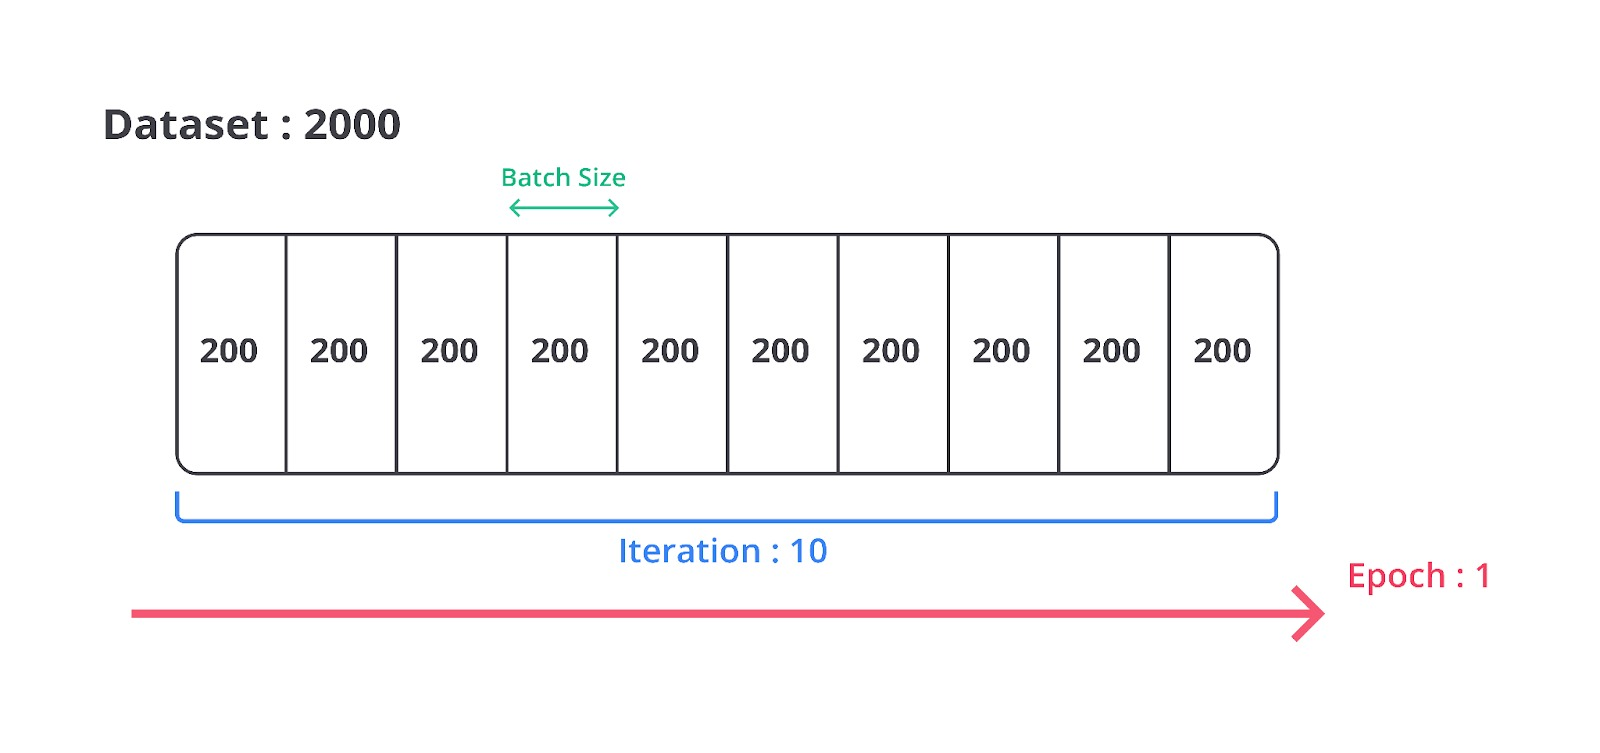



Apakah Anda sudah menyadari apa fungsi dari batch loading? Yup benar, dengan batch loading proses pelatihan data akan menjadi lebih cepat. Kita akan melihat langsung kegunaan dari batch loading pada latihan berikut.

Untuk dataset, kita akan menggunakan dataset mnist dan model yang sama dengan materi sebelumnya.

In [22]:
mnist = tf.keras.datasets.mnist
(training_images, training_labels), (test_images, test_labels) = mnist.load_data()
training_images  = training_images / 255.0
test_images = test_images / 255.0
model = tf.keras.models.Sequential([tf.keras.layers.Flatten(input_shape=(28,28)),
                                    tf.keras.layers.Dense(128, activation=tf.nn.relu),
                                    tf.keras.layers.Dense(10, activation=tf.nn.softmax)])
model.compile(optimizer = tf.optimizers.Adam(),
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Selanjutnya, buatlah fungsi fit() untuk melakukan pelatihan. Perlu Anda perhatikan, di sini kita mulai menggunakan batch loading. Untuk menggunakan batch loading, kita hanya menambahkan satu parameter ‘batch_size’ pada fungsi fit().

Tahukah Anda bahwa fungsi fit() secara default menggunakan batch loading dengan batch size sebesar 32. Sehingga, ketika kita tidak mendefinisikan nilai parameter batch_size, ukuran batch akan diisi sebesar 32 secara default. Perhatikan bahwa pada setiap epoch memakan waktu selama sekitar 3 atau 4 detik.

In [23]:
model.fit(training_images, training_labels, batch_size=32, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8737 - loss: 0.4319
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9639 - loss: 0.1214
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9765 - loss: 0.0811
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9830 - loss: 0.0577
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9873 - loss: 0.0427


Agar lebih paham, sekarang kita akan menggunakan batch_size yang lebih besar yaitu 128. Dapat kita lihat bahwa semakin besar batch size, waktu eksekusi tiap epoch akan semakin cepat.

In [ ]:
model.fit(training_images, training_labels, batch_size=128, epochs=5)

Seperti yang Anda lihat di atas, waktu pelatihan yang dilakukan memakan waktu yang lebih singkat. Silakan Anda bereksperimen menggunakan batch size yang lain untuk pengalaman belajar yang lebih maksimal. Bagaimana hasilnya? Silakan beri kesimpulan sendiri, ya.

Pada latihan ini, kita telah memahami bahwa dengan menggunakan batch loading dapat mempercepat pelatihan. Untuk pemilihan batch size sendiri tidak ada aturan bakunya, tetapi yang umum dipakai adalah 32, 64, dan 128. Anda harus bereksperimen sendiri guna menemukan batch size yang cocok dengan masalah atau model yang sedang dibangun.

Sungguh tidak terasa kini kita sudah berada di penghujung modul. Menjelang perpisahan sementara ini, semoga semangat kita masih membara seperti sediakala. Selain itu, lakukan eksperimen segila mungkin agar mendapatkan pengalaman maksimal.

Simpan antusias Anda karena pada modul berikutnya kita akan mempelajari berbagai macam penerapan neural network untuk setiap tipe data yang ada. Selain itu, kita juga akan mempelajari beberapa studi kasus yang umum terjadi di industri saat ini.

Selamat karena sampai titik ini Anda semakin dekat dengan karier impian sebagai seorang machine learning engineer. Sampai jumpa di modul selanjutnya, ya!